In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import xmitgcm # High-level wrapper built on top of MITgcmutils, Internally, xmitgcm calls MITgcmutils.rdmds to read the raw files.
import matplotlib.pyplot as plt

import warnings; warnings.filterwarnings("ignore")

In [2]:
run_dir_srl = "/scratch2/tshahriar/DINO_1deg_outputs/runs/adjoint/toolchain_validation/DINO_1deg_tapAdj_ckpAll_5d_from180yrPk_viscRef_ReMax2_gmFwd_approxAdv_run31281/"

In [3]:
# --- Load MITgcm grid as an xarray Dataset (with coords) ---
ds_grid = xmitgcm.open_mdsdataset(
    run_dir_srl,
    grid_dir=run_dir_srl,
    geometry="curvilinear",
    iters=None,          # grid only
    prefix=None,
    delta_t=1800,        # your model deltaT
)

# Grab lon/lat at tracer (C) points
XC = ds_grid["XC"]   # dims usually ('j','i') or ('j','i_g') depending on grid
YC = ds_grid["YC"]

print("XC dims:", XC.dims, "shape:", XC.shape)
print("YC dims:", YC.dims, "shape:", YC.shape)

XC dims: ('j', 'i') shape: (198, 51)
YC dims: ('j', 'i') shape: (198, 51)


In [4]:
print(ds_grid)

<xarray.Dataset>
Dimensions:    (i: 51, i_g: 51, j: 198, j_g: 198, k: 36, k_u: 36, k_l: 36,
                k_p1: 37)
Coordinates: (12/45)
  * i          (i) int64 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49 50
  * i_g        (i_g) int64 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49 50
  * j          (j) int64 0 1 2 3 4 5 6 7 8 ... 190 191 192 193 194 195 196 197
  * j_g        (j_g) int64 0 1 2 3 4 5 6 7 8 ... 190 191 192 193 194 195 196 197
  * k          (k) int64 0 1 2 3 4 5 6 7 8 9 ... 26 27 28 29 30 31 32 33 34 35
  * k_u        (k_u) int64 0 1 2 3 4 5 6 7 8 9 ... 26 27 28 29 30 31 32 33 34 35
    ...         ...
    maskCtrlW  (k, j, i_g) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    maskCtrlS  (k, j_g, i) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    dxF        (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF        (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV        (j_g, i_g) >f4 dask.array<

In [5]:
# --- Build a visible (i, j) -> (lon, lat) mapping table inside the notebook ---
# Use the actual dimension names from XC (commonly 'j' and 'i')
jdim, idim = XC.dims

j_vals = ds_grid[jdim].values
i_vals = ds_grid[idim].values

# Make MITgcm-style 1-based indices
I, J = np.meshgrid(np.arange(1, len(i_vals)+1), np.arange(1, len(j_vals)+1))

# Flatten mapping
ij_lonlat = xr.Dataset(
    data_vars=dict(
        lon=(("points",), XC.values.ravel()),
        lat=(("points",), YC.values.ravel()),
        i=(("points",), I.ravel()),
        j=(("points",), J.ravel()),
    )
)

In [6]:
ij_lonlat.to_dataframe().head(50)

,lon,lat,i,j
points,,,,
0,-50.5,-69.851738,1,1
1,-49.5,-69.851738,2,1
2,-48.5,-69.851738,3,1
3,-47.5,-69.851738,4,1
4,-46.5,-69.851738,5,1
5,-45.5,-69.851738,6,1
6,-44.5,-69.851738,7,1
7,-43.5,-69.851738,8,1
8,-42.5,-69.851738,9,1


In [7]:
# --- Helper: query lon/lat for a given (i, j) (MITgcm 1-based indexing) ---
def ij_to_lonlat(i, j):
    # convert to python 0-based
    return float(XC.values[j-1, i-1]), float(YC.values[j-1, i-1])

lon, lat = ij_to_lonlat(i=1, j=127)
print(f"(i=, j=) -> lon={lon:.3f}, lat={lat:.3f}")

(i=, j=) -> lon=-50.500, lat=26.053


In [27]:
# --- Find the closest J to a target latitude (e.g. 26°N) ---
target_lat = 10

# In your grid, latitude is effectively a function of j only, so take a single i-column
YC_1d = YC.isel({idim: 0}).values
j_closest = int(np.argmin(np.abs(YC_1d - target_lat)) + 1)

print(f"Closest to {target_lat}°N: J = {j_closest}, lat = {YC_1d[j_closest-1]:.6f}")

Closest to 10°N: J = 110, lat = 9.949614


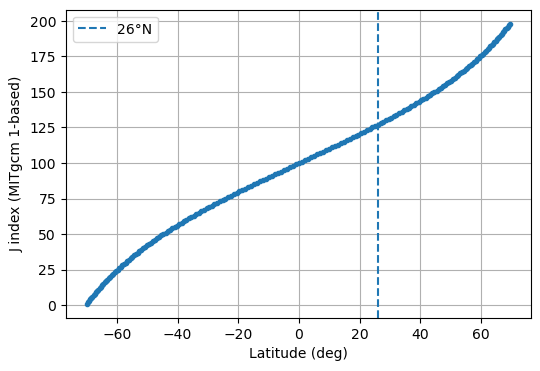

In [9]:
# --- Visual mapping: latitude vs J index (makes it obvious in the notebook) ---
Ny = YC_1d.size
plt.figure(figsize=(6,4))
plt.plot(YC_1d, np.arange(1, Ny+1), marker=".", linestyle="none")
plt.axvline(26.0, linestyle="--", label="26°N")
plt.xlabel("Latitude (deg)")
plt.ylabel("J index (MITgcm 1-based)")
plt.grid(True)
plt.legend()
plt.show()